# Практическая работа №3

## Поиск изображений по содержанию

## Задание

### Цель

Знакомство с методами поиска изображений по содержанию, формирование навыков реализации методов поиска по содержанию на языке Python.

### Задачи

Выполнение практической работы направлено на исследование методов поиска изображений по содержанию

## Ход работы

### Импорты и вспомогательные функции

### Подготовка окружения

Устанавливаю необходимые зависимости перед импортом модулей.


In [1]:
%pip install numpy scipy scikit-image matplotlib opencv-contrib-python imagehash pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/4.3 MB ? eta -:--:--


   ━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.8/4.3 MB 4.6 MB/s eta 0:00:01


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺ 4.2/4.3 MB 10.9 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 10.7 MB/s  0:00:00



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imagehash]



Note: you may need to restart the kernel to use updated packages.


In [2]:
import os
import math
import numpy as np
import skimage
from skimage import img_as_float, img_as_ubyte, morphology
from skimage.color import rgb2gray
from skimage.exposure import histogram
from skimage.feature import graycomatrix, graycoprops
from PIL import Image
import imagehash
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update(
    {
        # корректное отображение ЧБ изображений в Matplotlib
        'image.cmap': 'gray',
        'axes.titlesize': 10,
    }
)

In [3]:
# отрисовка изображений в виде сетки
# images - словарь {название изображения: изображение}
def display_images(images, ncolumns: int = 1) -> None:
    nrows = math.ceil(len(images) / ncolumns)
    fig, axes = plt.subplots(nrows, ncolumns, figsize=(2*ncolumns, 3 * nrows))
    axes = axes.flatten()
    
    for ax, (title, image) in zip(axes, images.items()):
        ax.axis('off')
        ax.imshow(image)
        ax.set_title(title)
    
    for i in range(len(images), len(axes)):
        axes[i].axis('off')
        fig.tight_layout()
        plt.show()
    
def get_filename_without_extension(path: str) -> str:
    return Path(path).stem

### Подготовка изображений для исследования

In [4]:
path_base = 'data'
path_color = os.path.join(path_base, 'color')
path_shape = os.path.join(path_base, 'shape')
path_texture = os.path.join(path_base, 'texture')

color_images = dict()
lsh_images = dict()
for filename in os.listdir(path_color):
    color_images[get_filename_without_extension(filename)] = skimage.io.imread(os.path.join(path_color, filename))
    lsh_images[get_filename_without_extension(filename)] = Image.open(os.path.join(path_color, filename))

shape_images = dict()
for filename in os.listdir(path_shape):
    image_pil = Image.open(os.path.join(path_shape, filename)).convert('RGBA')
    image_np = np.array(image_pil)
    transparent_mask = image_np[:, :, 3] == 0
    image_np[transparent_mask] = [0, 0, 0, 255]
    shape_images[get_filename_without_extension(filename)] = image_np[:, :, :3]

texture_images = dict()
for filename in os.listdir(path_texture):
    texture_images[get_filename_without_extension(filename)] = skimage.io.imread(os.path.join(path_texture, filename))

color_base = 'tulip_red1'
shape_base = 'banana1'
texture_base = 'porous_0040'

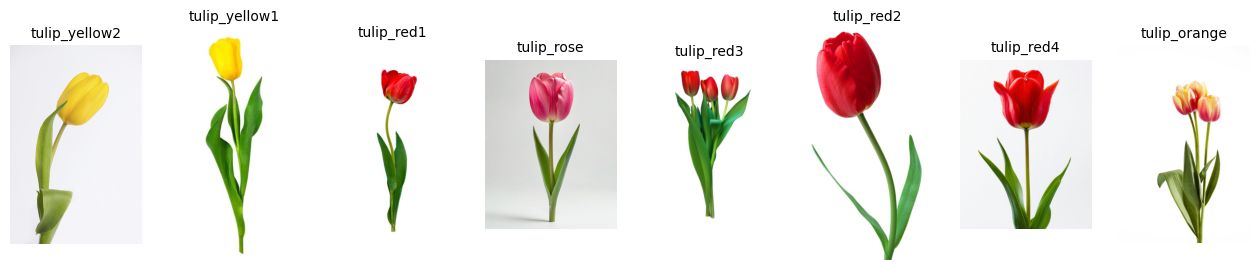

In [5]:
display_images(color_images, len(color_images))

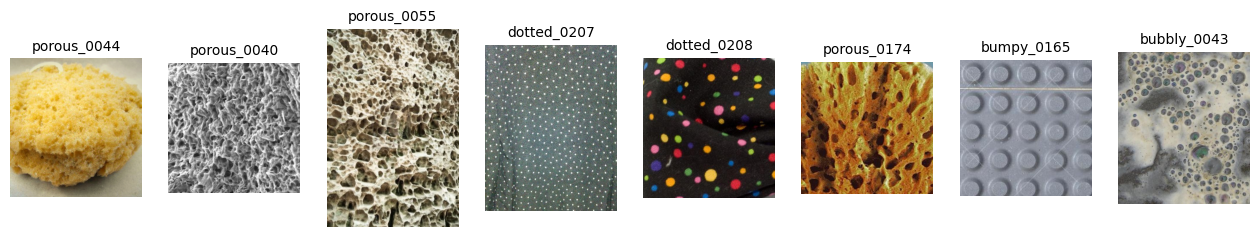

In [6]:
display_images(texture_images, len(texture_images))

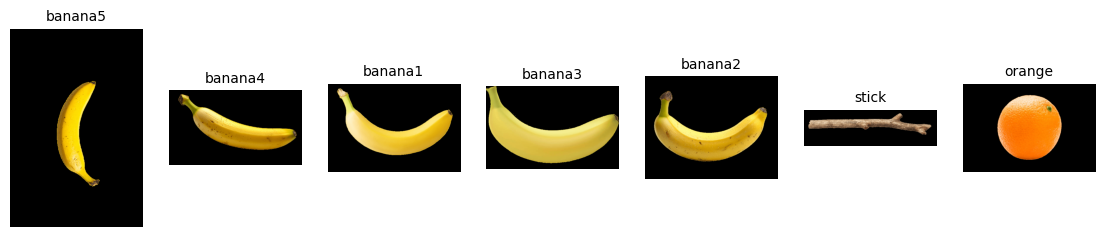

In [7]:
display_images(shape_images, len(shape_images))

### Сравнение признаков цвета

Для каждого канала цветного изображения выполняется построение гистограммы интенсивности пикселей. Полученные гистограммы преобразуются в вектор. Схожесть изображений по цвету определяется как мера косунусного сходства их векторов цветов.

In [8]:
def get_color_histograms(image, threshold=240, nbins=32):
    image_hists, image_bins = [], []
    for channel in range(3):
        mask = image[..., channel] < threshold
        hist, bins = histogram(img_as_float(image[..., channel][mask]), normalize=True, nbins=nbins)
        image_hists.append(hist)
        image_bins.append(bins)
    return image_hists, image_bins

def get_color_vector(image, threshold=240, nbins=32):
    image_hists = []
    for channel in range(3):
        mask = image[..., channel] < threshold
        hist, _ = histogram(img_as_float(image[..., channel][mask]), normalize=True, nbins=nbins)
        image_hists.append(hist)
    return np.concatenate(image_hists, axis=0)

def cosine_similarity(vector1, vector2):
    return np.dot(vector1, vector2) / (np.linalg.norm(vector1) * np.linalg.norm(vector2))

def display_images_with_histograms(images, threshold, nbins, ncolumns: int = 1) -> None:
    nrows = math.ceil(len(images) / ncolumns)
    fig, axes = plt.subplots(nrows * 2, ncolumns, figsize=(3 * ncolumns, 4 * nrows * 2))
    axes = axes.reshape(nrows * 2, ncolumns)
    
    for idx, (title, image) in enumerate(images.items()):
        row = (idx // ncolumns) * 2
        col = idx % ncolumns
        
        ax_img = axes[row, col]
        ax_img.axis('off')
        ax_img.imshow(image)
        ax_img.set_title(title)
        
        ax_hist = axes[row + 1, col]
        
        image_hists, image_bins = get_color_histograms(image, threshold=threshold, nbins=nbins)
        for hist, bins, color in zip(image_hists, image_bins, ['r', 'g', 'b']):
            ax_hist.plot(bins, hist, color=color)
        
        ax_hist.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
        ax_hist.set_xlabel('Pixel intensity')
        ax_hist.set_ylabel('Pixels fraction')
        
    for i in range(len(images), nrows * ncolumns):
        axes[(i // ncolumns) * 2, i % ncolumns].axis('off')
        axes[(i // ncolumns) * 2 + 1, i % ncolumns].axis('off')
        
    fig.tight_layout()
    plt.show()

def color_based_search(query_image, images, threshold=240, nbins=32, ncolumns=1):
    query_vector = get_color_vector(query_image, threshold=threshold, nbins=nbins)
    similarities = {name: cosine_similarity(query_vector, get_color_vector(image, threshold=threshold, nbins=nbins)) for name, image in images.items()}
    similarities = {k: v for k, v in sorted(similarities.items(), key=lambda item: item[1], reverse=True)}
    display_images_with_histograms({f'{name}\nsimilarity: {similarities[name]:.4f}': images[name] for name in similarities}, threshold=threshold, nbins=nbins, ncolumns=ncolumns)

Видно, что некоторые красные тюльпаны оказались менее похожими на изображение-запрос. При определении сходства имеет значение не только оттенок бутона, но и цвет листьев и стебля.

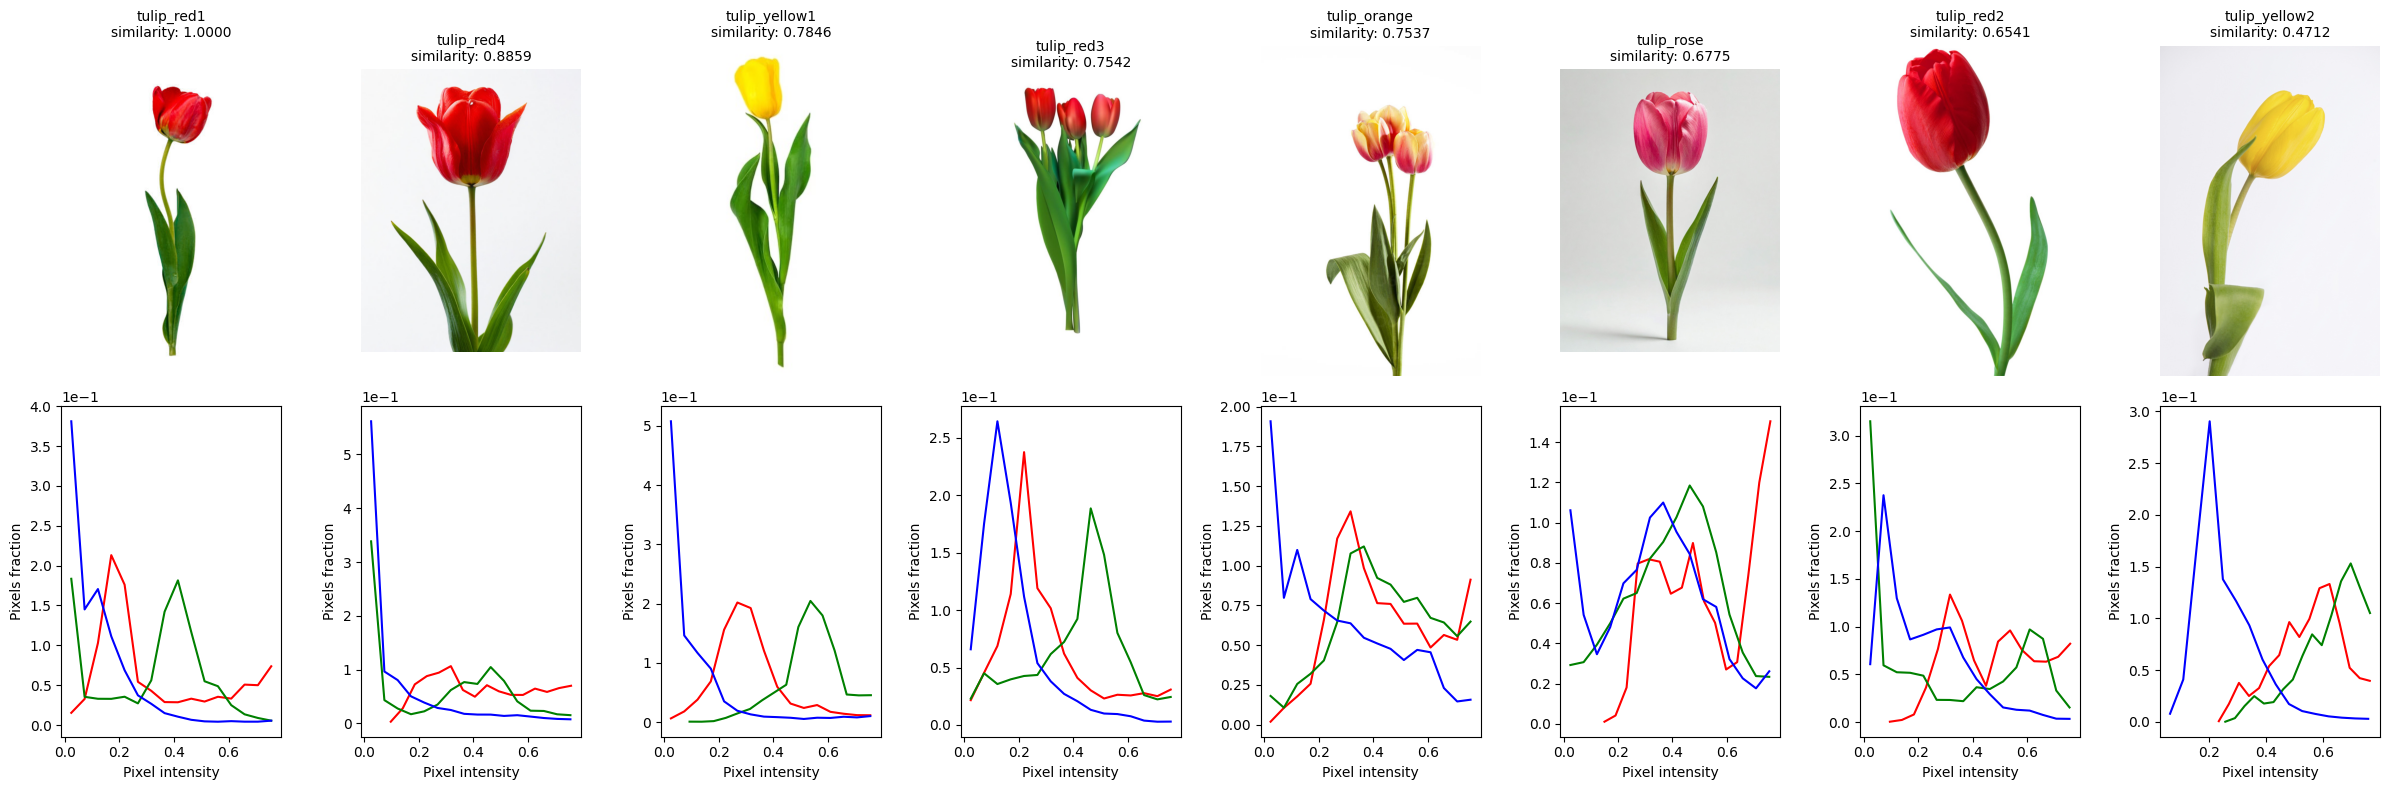

In [9]:
color_based_search(color_images[color_base], color_images, threshold=200, nbins=16, ncolumns=len(color_images))

### Сравнение признаков текстуры

Для определения текстурного сходства используется матрица совместной встерчаемости уровня серого для полутонового изображения.
Для матрицы определяются следующие характеристики:
- контраст
- несхожесть
- однородность
- энергия
- корреляция

В качестве меры сходства используется Евклидово расстояние по перечисленным характеристикам.

In [10]:
def extract_texture_features(image):
    image_gray = img_as_float(rgb2gray(image))
    glcm = graycomatrix((image_gray * 255).astype(np.uint8), distances=[1], angles=[0], levels=256, symmetric=True, normed=True)
    
    contrast = graycoprops(glcm, 'contrast')[0][0]
    dissimilarity = graycoprops(glcm, 'dissimilarity')[0][0]
    homogeneity = graycoprops(glcm, 'homogeneity')[0][0]
    energy = graycoprops(glcm, 'energy')[0][0]
    correlation = graycoprops(glcm, 'correlation')[0][0]
    return np.array([contrast, dissimilarity, homogeneity, energy, correlation])

Были получены правдоподобные результаты для исследуемых изображений.

/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/opt/homebrew/Cellar/jupyterlab/4.4.7/libexec/lib/python3.13/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs


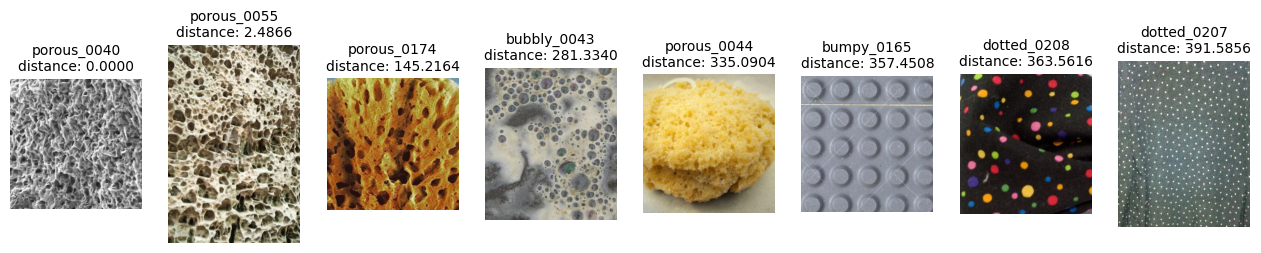

In [11]:
base_features = extract_texture_features(texture_images[texture_base])

similarities = {}
for name, image in texture_images.items():
    features = extract_texture_features(image)
    distance = np.linalg.norm(base_features - features)
    similarities[name] = distance

similarities = {k: v for k, v in sorted(similarities.items(), key=lambda item: item[1])}

display_images({f'{name}\ndistance: {similarities[name]:.4f}': texture_images[name] for name in similarities}, ncolumns=len(similarities))

### Сравнение признаков формы

Для сравнения признаков формы используется сопоставление проекций бинаризованных изображений.
В качестве меры близости используется пересечение гистограмм проекций.

In [12]:
def compute_histogram(image, binary_threshold=0.1):
    binary_image = img_as_ubyte(img_as_float(rgb2gray(image)) >= binary_threshold)
    binary_image = morphology.remove_small_objects(binary_image, min_size=200)
    hist_x = np.sum(binary_image, axis=0)
    hist_y = np.sum(binary_image, axis=1)
    
    hist_x = hist_x / np.sum(hist_x)
    hist_y = hist_y / np.sum(hist_y)
    
    return np.concatenate((hist_x, hist_y))


def reshape_histogram(hist, target_size):
    return np.interp(np.linspace(0, len(hist), target_size), np.arange(len(hist)), hist)

def histogram_intersection(hist1, hist2):
    return np.sum(np.minimum(hist1, hist2))

def display_images_with_shape_histograms(images, histograms, ncolumns: int = 1) -> None:
    nrows = math.ceil(len(images) / ncolumns)
    fig, axes = plt.subplots(nrows * 2, ncolumns, figsize=(3 * ncolumns, 4 * nrows * 2))
    axes = axes.reshape(nrows * 2, ncolumns)
    
    for idx, (title, image) in enumerate(images.items()):
        row = (idx // ncolumns) * 2
        col = idx % ncolumns
        
        ax_img = axes[row, col]
        ax_img.axis('off')
        ax_img.imshow(image)
        ax_img.set_title(title)
        
        ax_hist = axes[row + 1, col]
        
        hist = histograms[title]
        ax_hist.plot(list(range(len(hist))), hist, color='black')
        
        ax_hist.ticklabel_format(axis='y', style='scientific', scilimits=(0, 0))
        ax_hist.set_xlabel('Row num')
        ax_hist.set_ylabel('Pixels fraction')
        
    for i in range(len(images), nrows * ncolumns):
        axes[(i // ncolumns) * 2, i % ncolumns].axis('off')
        axes[(i // ncolumns) * 2 + 1, i % ncolumns].axis('off')
        
    fig.tight_layout()
    plt.show()


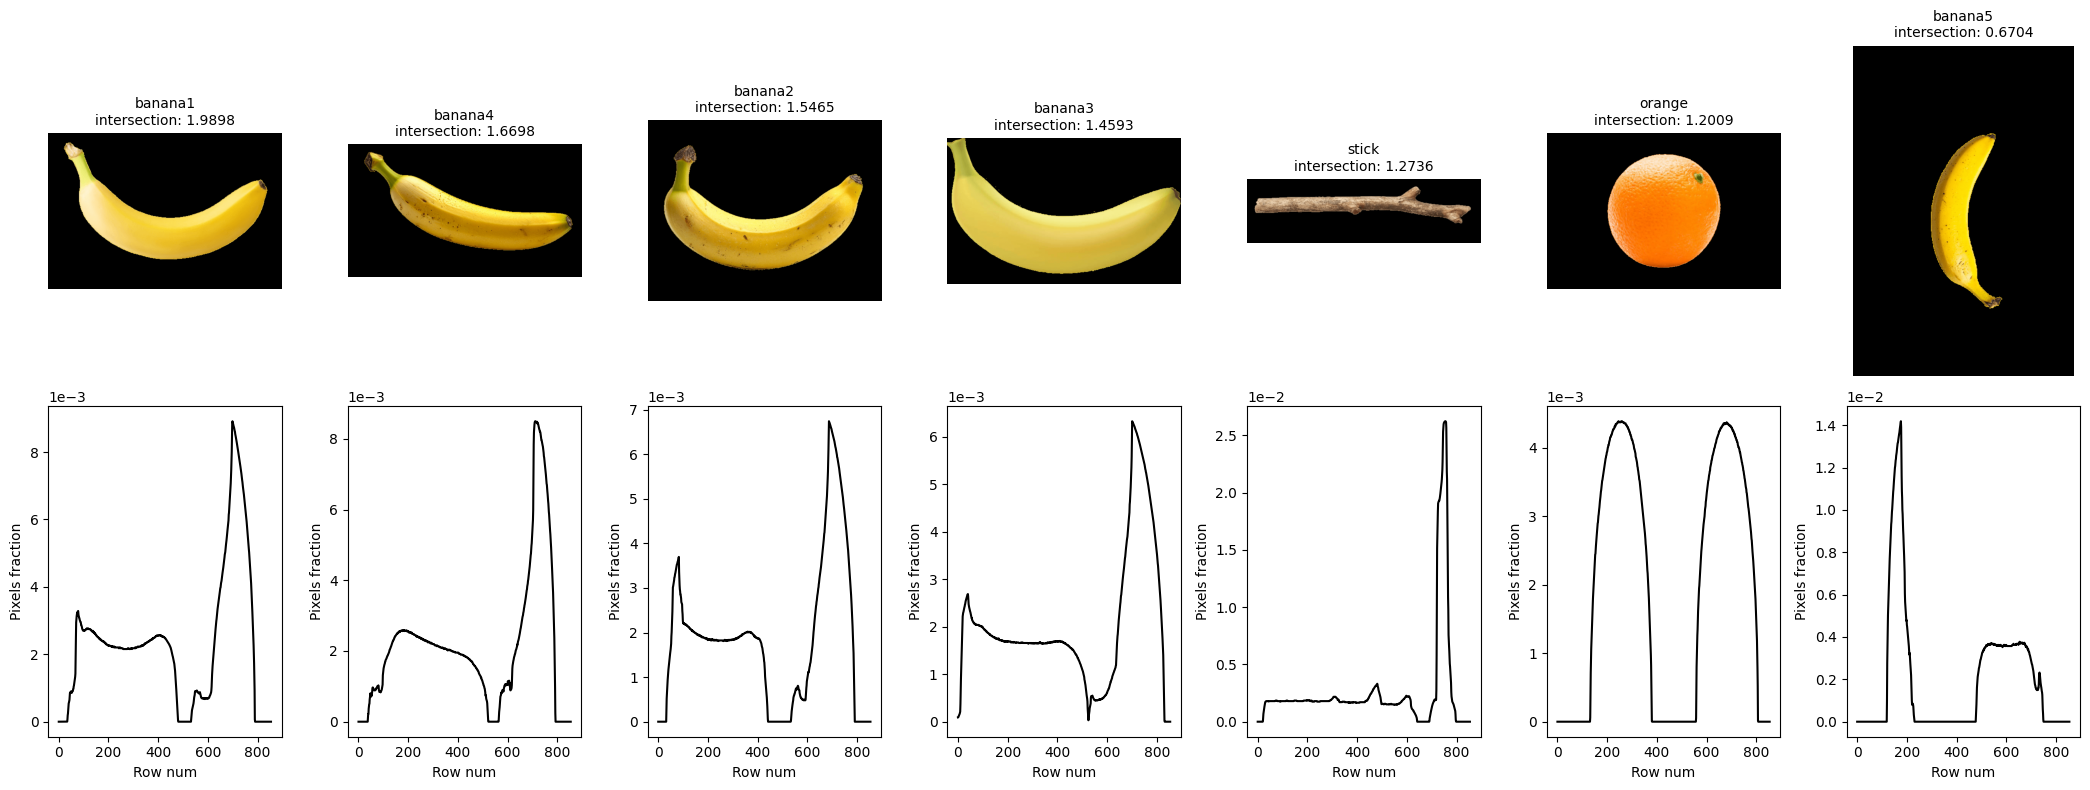

In [13]:
base_histogram = compute_histogram(shape_images[shape_base])

similarities = {}
histograms = {}
for name, image in shape_images.items():
    histogram = compute_histogram(image)
    histogram = reshape_histogram(histogram, len(base_histogram))
    similarity = histogram_intersection(base_histogram, histogram)
    similarities[name] = similarity
    histograms[name] = histogram

similarities = {k: v for k, v in sorted(similarities.items(), key=lambda item: item[1], reverse=True)}

display_images_with_shape_histograms({f'{name}\nintersection: {similarities[name]:.4f}': shape_images[name] for name in similarities}, {f'{name}\nintersection: {similarities[name]:.4f}': histograms[name] for name in histograms}, ncolumns=len(similarities))

### LSH

Для определения хэша изображения используется библиотека imagehash.
Схожесть изображений определяется как расстояние Хэмминга между хэшами изображений.

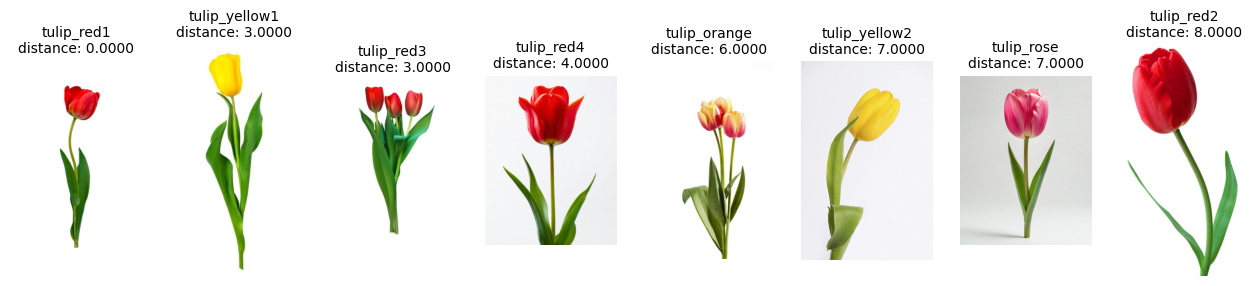

In [14]:
base_hash = imagehash.colorhash(lsh_images[color_base])

similarities = {}
for name, image in lsh_images.items():
    hash = imagehash.colorhash(image)
    similarity = base_hash - hash
    similarities[name] = similarity

similarities = {k: v for k, v in sorted(similarities.items(), key=lambda item: item[1])}

display_images({f'{name}\ndistance: {similarities[name]:.4f}': lsh_images[name] for name in similarities}, ncolumns=len(similarities))

## Вывод

Были рассмотрены различные методы поиска изображений по содержанию, и изучены способы их применения.